###**EDA & Preprocessing:** Data cleaning, exploratory analysis, encoding, scaling, SMOTE for class imbalance.

In [3]:
import pandas as pd

df = pd.read_csv('/content/Bank Customer Churn Prediction.csv')
df_reviews = pd.read_csv('/content/bank_reviews3.csv')

print("Churn dataset:")
print(df.columns.tolist())
print(df.shape)
print()
print("Reviews dataset:")
print(df_reviews.columns.tolist())
print(df_reviews.shape)

Churn dataset:
['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']
(10000, 12)

Reviews dataset:
['author', 'date', 'address', 'bank', 'rating', 'review_title_by_user', 'review', 'bank_image', 'rating_title_by_user', 'useful_count']
(1000, 10)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

plt.style.use('seaborn-v0_8-whitegrid')
print("Imports done")

Imports done


In [7]:
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nChurn rate:", df['churn'].mean().round(3))
df.head()

customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

Missing values:
 customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Churn rate: 0.204


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


churn
0    7963
1    2037
Name: count, dtype: int64


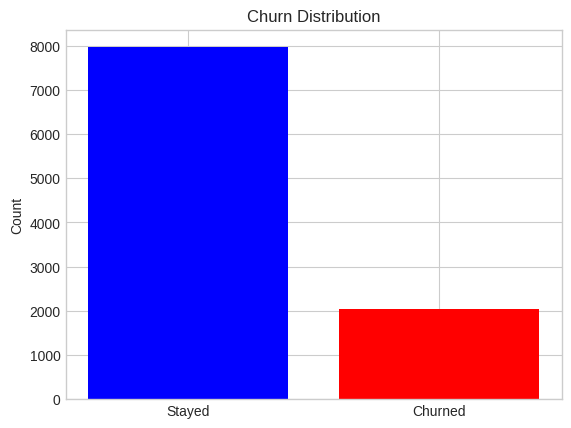

In [16]:
counts = df['churn'].value_counts()
print(counts)

plt.bar(['Stayed', 'Churned'], counts, color=['blue', 'red'])
plt.title('Churn Distribution')
plt.ylabel('Count')
plt.show()

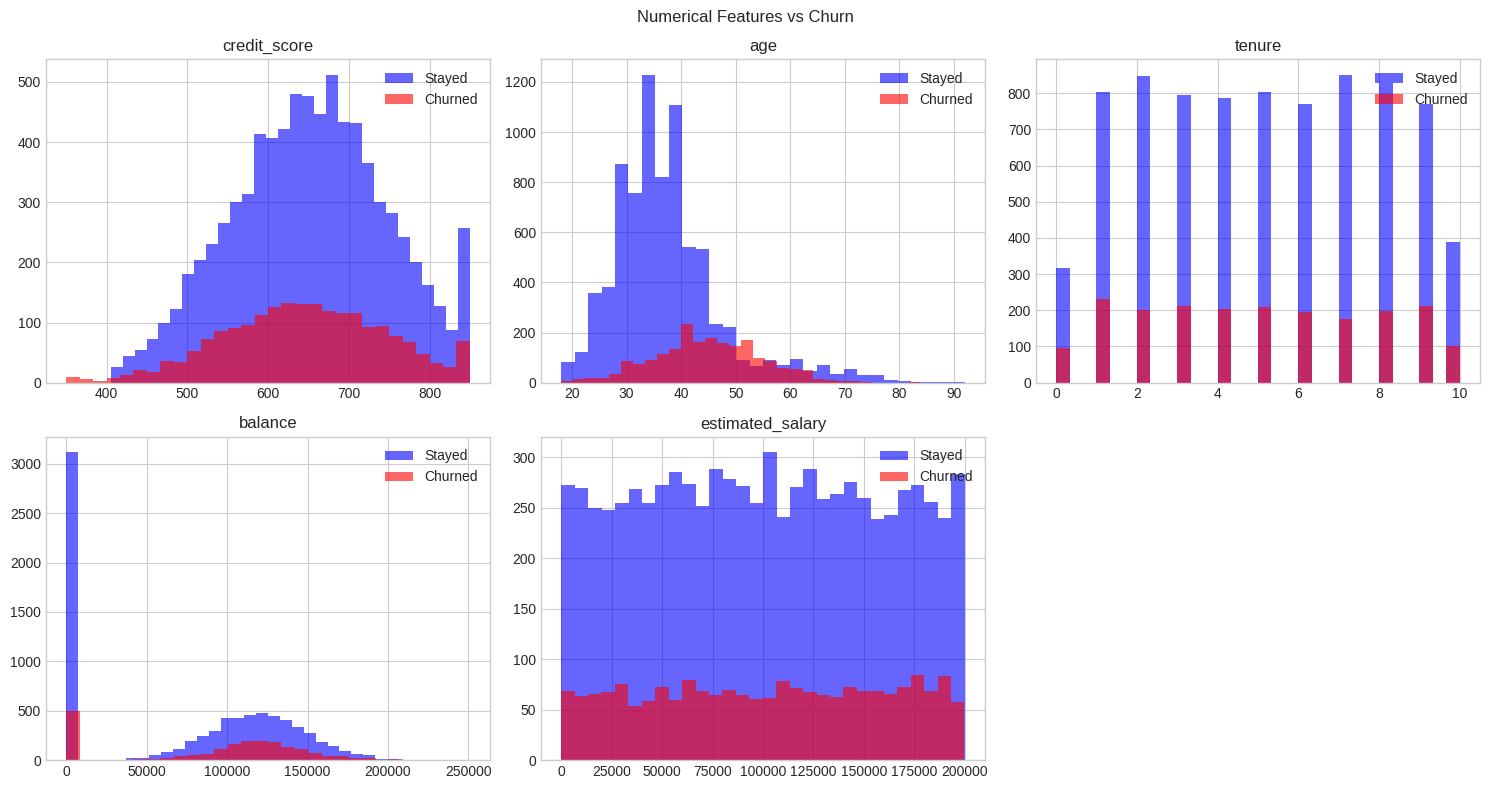

In [17]:
# checking how numerical features look for churned vs stayed customers
num_cols = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[df['churn']==0][col], alpha=0.6, label='Stayed', color='blue', bins=30)
    axes[i].hist(df[df['churn']==1][col], alpha=0.6, label='Churned', color='red', bins=30)
    axes[i].set_title(col)
    axes[i].legend()

axes[5].axis('off')
plt.suptitle('Numerical Features vs Churn')
plt.tight_layout()
plt.show()

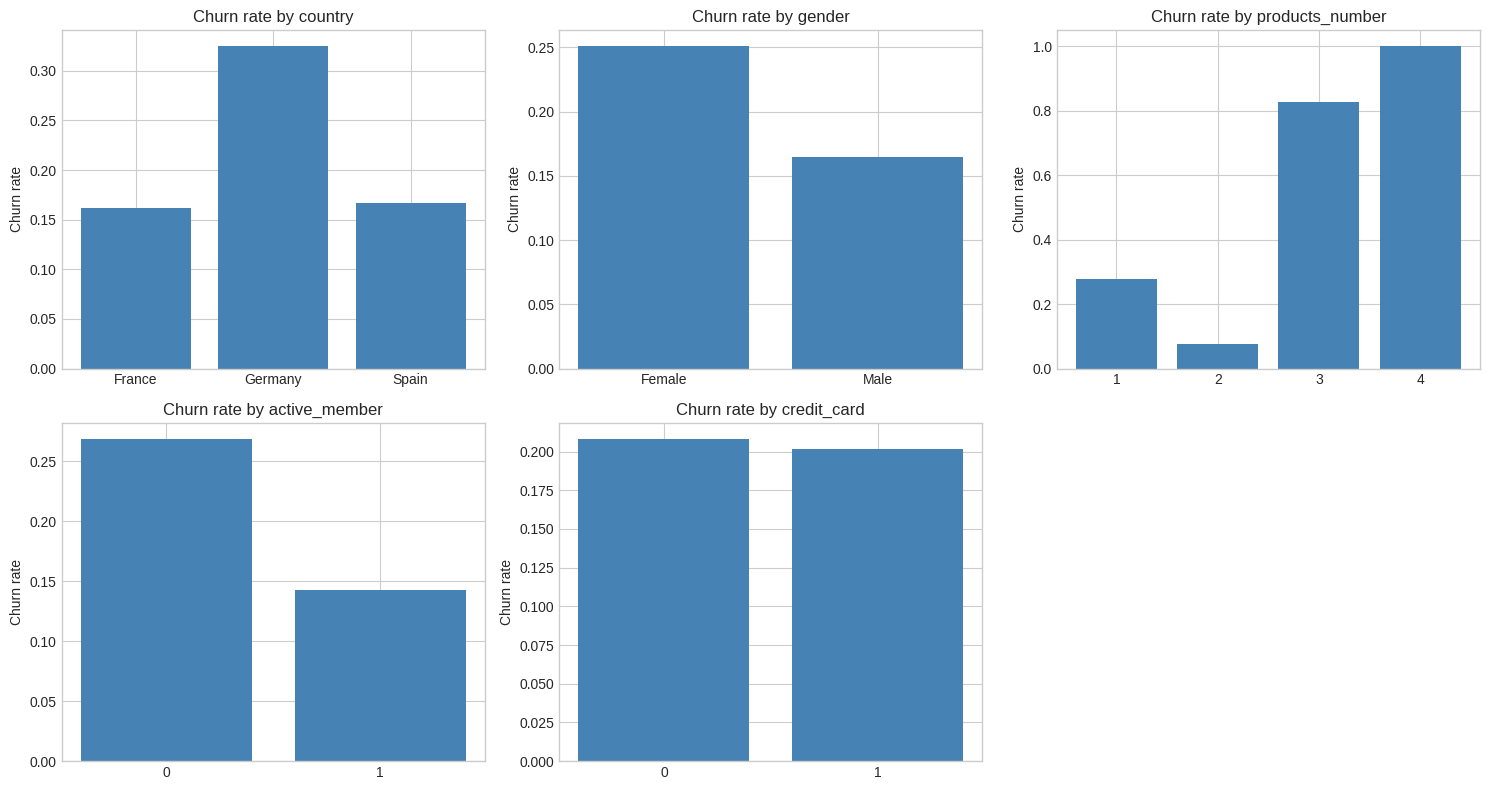

In [18]:
# seeing which categories have higher churn rate
cat_cols = ['country', 'gender', 'products_number', 'active_member', 'credit_card']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['churn'].mean()
    axes[i].bar(churn_rate.index.astype(str), churn_rate.values, color='steelblue')
    axes[i].set_title(f'Churn rate by {col}')
    axes[i].set_ylabel('Churn rate')

axes[5].axis('off')
plt.tight_layout()
plt.show()

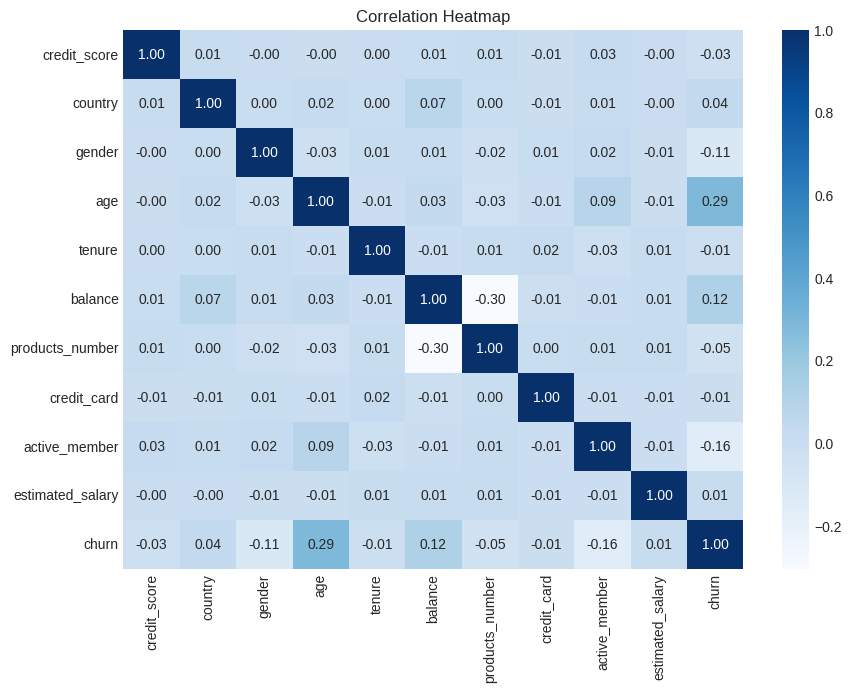

In [19]:
# checking correlation between features
df_encoded = df.copy()
df_encoded.drop('customer_id', axis=1, inplace=True)

le = LabelEncoder()
df_encoded['country'] = le.fit_transform(df_encoded['country'])
df_encoded['gender'] = le.fit_transform(df_encoded['gender'])

plt.figure(figsize=(10, 7))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

In [23]:
# copying encoded dataframe for modeling
df_model = df_encoded.copy()

# split features and target
X = df_model.drop('churn', axis=1)
y = df_model['churn']

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling numerical columns
scaler = StandardScaler()
num_cols = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# handling class imbalance using smote
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_res).value_counts().to_dict())
print("done - ready for phase 2")

Before SMOTE: {0: 6356, 1: 1644}
After SMOTE: {0: 6356, 1: 6356}
done - ready for phase 2


### **ML Models:** Logistic Regression baseline vs Random Forest, evaluated using classification report, confusion matrix and ROC-AUC curve.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [25]:
# logistic regression as baseline model
lr = LogisticRegression(random_state=42)
lr.fit(X_train_res, y_train_res)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1607
           1       0.38      0.68      0.49       393

    accuracy                           0.72      2000
   macro avg       0.64      0.70      0.65      2000
weighted avg       0.80      0.72      0.74      2000



In [26]:
# random forest main model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1607
           1       0.59      0.64      0.61       393

    accuracy                           0.84      2000
   macro avg       0.75      0.77      0.76      2000
weighted avg       0.85      0.84      0.84      2000



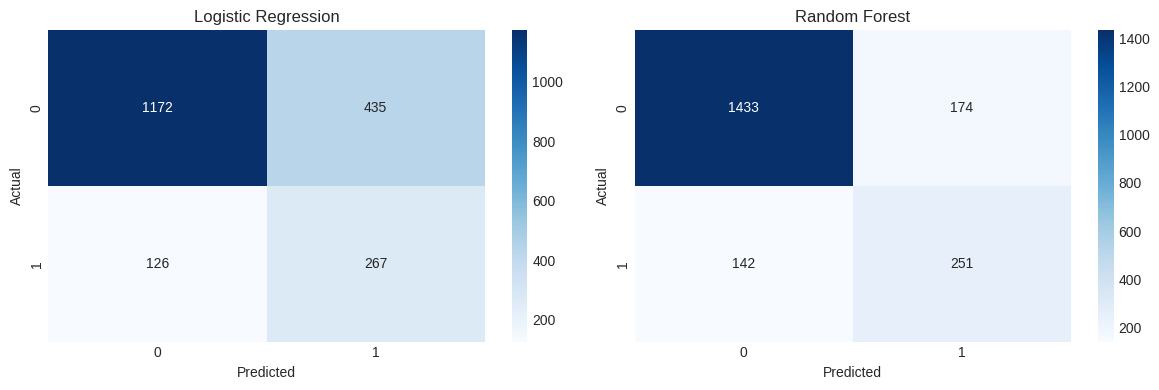

In [27]:
# confusion matrix for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# logistic regression
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d',
            cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# random forest
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d',
            cmap='Blues', ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

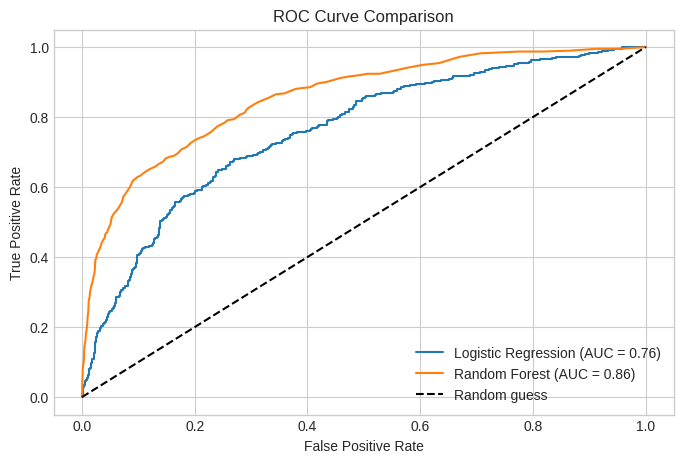

In [28]:
# roc curve to compare both models
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr.predict_proba(X_test)[:,1])
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])

lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

plt.figure(figsize=(8, 5))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.2f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot([0,1], [0,1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

###**SHAP Explainability:** Used SHAP TreeExplainer to interpret Random Forest predictions - feature importance bar plot, beeswarm plot for global insights, and waterfall plot for individual customer explanation.

In [30]:
!pip install shap -q

import shap

In [31]:
# creating shap explainer for random forest
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

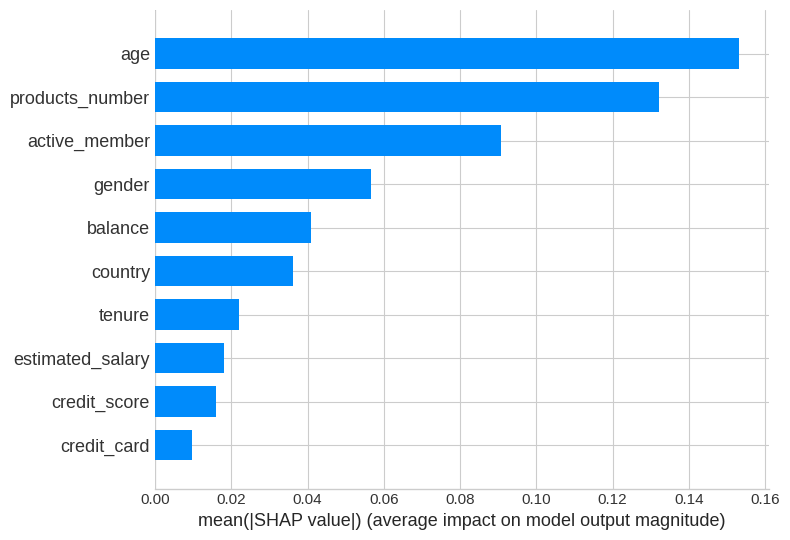

In [32]:
# overall feature importance - which features matter most
shap.summary_plot(shap_values[:,:,1], X_test, plot_type='bar',
                  feature_names=X_test.columns.tolist())

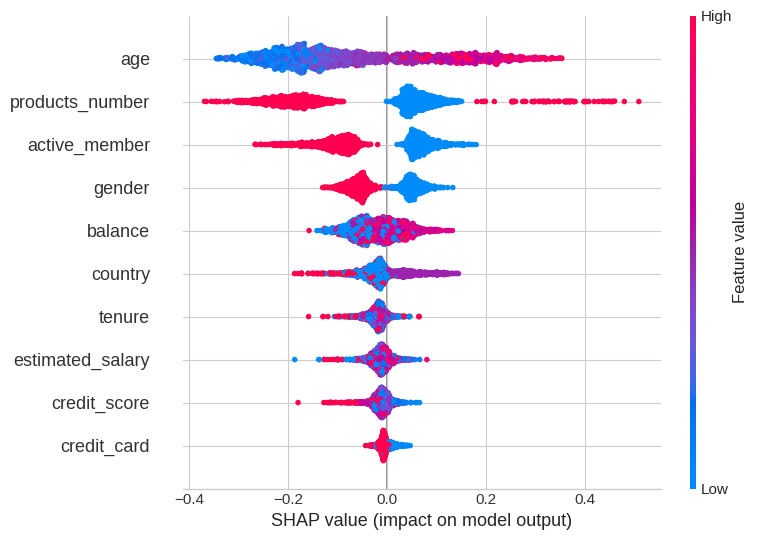

In [33]:
# how each feature affects churn prediction for every customer
shap.summary_plot(shap_values[:,:,1], X_test,
                  feature_names=X_test.columns.tolist())

###**NLP Sentiment Analysis**

In [35]:
print(df_reviews.shape)
print(df_reviews.columns.tolist())
df_reviews.head()

(1000, 10)
['author', 'date', 'address', 'bank', 'rating', 'review_title_by_user', 'review', 'bank_image', 'rating_title_by_user', 'useful_count']


,author,date,address,bank,rating,review_title_by_user,review,bank_image,rating_title_by_user,useful_count
0,AMRENDRA T,"Mar 21, 2020",New delhi,SBI,4.0,"""Best saving""",State Bank Of India is located nearby in our a...,https://static.bankbazaar.com/images/common/ba...,Great!,133
1,BISHWA,"Mar 20, 2020",Kolkata,SBI,5.0,"""Good service""","I have my salary account in SBI, when I applie...",https://static.bankbazaar.com/images/common/ba...,Blown Away!,89
2,SANTOSH,"Mar 20, 2020",Hooghly,Axis Bank,5.0,"""Excellent Service""",I am using Axis bank saving account for the p...,https://static.bankbazaar.com/images/common/ba...,Blown Away!,48
3,MAHADEV,"Mar 20, 2020",Pune,HDFC Bank,5.0,"""Excellent service""",I have my salary bank account in HDFC bank for...,https://static.bankbazaar.com/images/common/ba...,Blown Away!,52
4,R,"Mar 20, 2020",Bangalore,review,5.0,"""Good account""","Close to around 10 years, I am holding this Co...",https://static.bankbazaar.com/images/common/ba...,Blown Away!,22


In [36]:
# keeping only what we need
df_nlp = df_reviews[['review', 'rating']].copy()

# dropping empty reviews
df_nlp.dropna(subset=['review'], inplace=True)

print(df_nlp.shape)
print(df_nlp['rating'].value_counts())

(1000, 2)
rating
5.0    550
4.0    257
3.0     71
4.5     45
2.0     30
3.5     21
1.0     13
0.5     10
2.5      2
1.5      1
Name: count, dtype: int64


In [38]:
!pip install textblob -q
from textblob import TextBlob

# getting sentiment polarity for each review
def get_sentiment(text):
    score = TextBlob(str(text)).sentiment.polarity
    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral'

df_nlp['polarity'] = df_nlp['review'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df_nlp['sentiment'] = df_nlp['review'].apply(get_sentiment)

print(df_nlp['sentiment'].value_counts())
df_nlp.head()

sentiment
positive    880
negative    105
neutral      15
Name: count, dtype: int64


,review,rating,polarity,sentiment
0,State Bank Of India is located nearby in our a...,4.0,0.421111,positive
1,"I have my salary account in SBI, when I applie...",5.0,0.400000,positive
2,I am using Axis bank saving account for the p...,5.0,0.150000,positive
3,I have my salary bank account in HDFC bank for...,5.0,0.460000,positive
4,"Close to around 10 years, I am holding this Co...",5.0,0.383333,positive


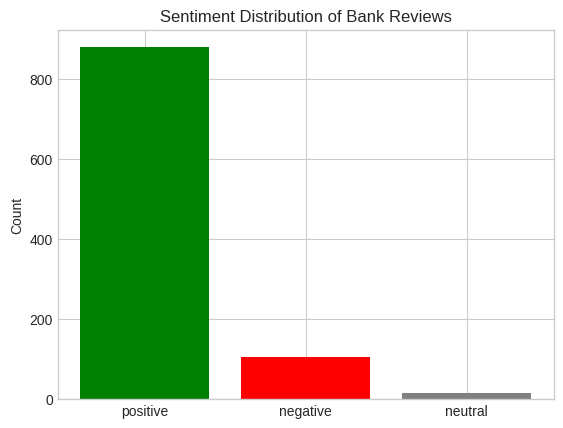

In [40]:
sentiment_counts = df_nlp['sentiment'].value_counts()

plt.bar(sentiment_counts.index, sentiment_counts.values,
        color=['green', 'red', 'gray'])
plt.title('Sentiment Distribution of Bank Reviews')
plt.ylabel('Count')
plt.show()

rating
5    550
4    323
3     71
2     33
1     13
0     10
Name: count, dtype: int64


<Figure size 800x500 with 0 Axes>

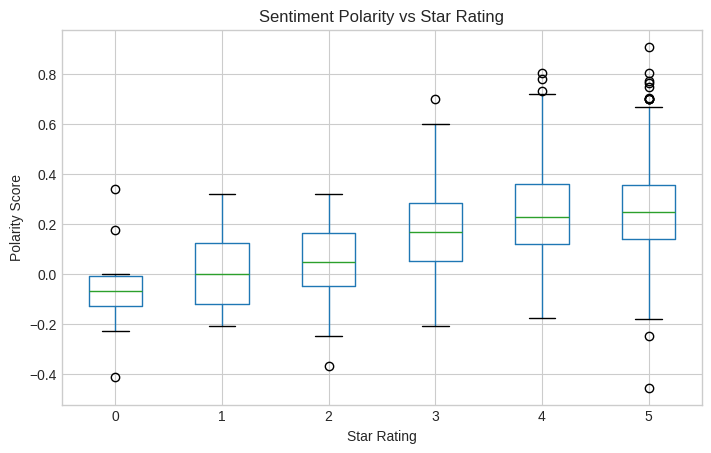

In [41]:
# rounding ratings to whole numbers
df_nlp['rating'] = df_nlp['rating'].round().astype(int)
print(df_nlp['rating'].value_counts())

# checking if sentiment matches the star rating
plt.figure(figsize=(8, 5))
df_nlp.boxplot(column='polarity', by='rating', figsize=(8, 5))
plt.title('Sentiment Polarity vs Star Rating')
plt.suptitle('')
plt.xlabel('Star Rating')
plt.ylabel('Polarity Score')
plt.show()

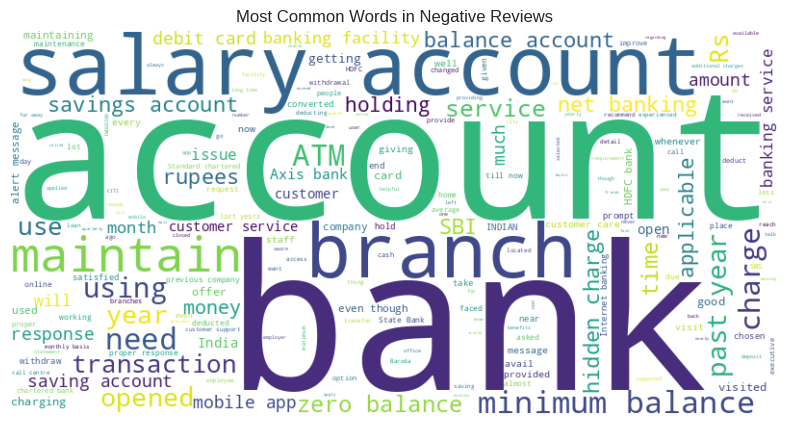

In [42]:
!pip install wordcloud -q
from wordcloud import WordCloud

# most common words in negative reviews
negative_reviews = ' '.join(df_nlp[df_nlp['sentiment'] == 'negative']['review'].tolist())

wordcloud = WordCloud(width=800, height=400,
                      background_color='white').generate(negative_reviews)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Reviews')
plt.show()

In [43]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 21.9 MB/s eta 0:00:00


In [44]:
import joblib

joblib.dump(rf, 'rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
df_nlp.to_csv('reviews_sentiment.csv', index=False)

print("models saved")

models saved


In [48]:
from google.colab import files

files.download('rf_model.pkl')
files.download('scaler.pkl')
files.download('reviews_sentiment.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
import pandas as pd
import numpy as np
import joblib
import shap

rf = joblib.load('rf_model.pkl')
scaler = joblib.load('scaler.pkl')

country_map = {"France": 0, "Germany": 1, "Spain": 2}
gender_map = {"Male": 1, "Female": 0}

# test prediction manually
input_data = pd.DataFrame({
    'credit_score': [600],
    'country': [0],
    'gender': [1],
    'age': [35],
    'tenure': [5],
    'balance': [50000],
    'products_number': [1],
    'credit_card': [1],
    'active_member': [1],
    'estimated_salary': [50000]
})

num_cols = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']
input_data[num_cols] = scaler.transform(input_data[num_cols])

prob = rf.predict_proba(input_data)[0][1]
print("Churn probability:", prob)

Churn probability: 0.35


In [50]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(input_data)
print(type(shap_values))
print(len(shap_values))
print(shap_values)

<class 'numpy.ndarray'>
1
[[[-0.01021467  0.01021467]
  [ 0.02037316 -0.02037316]
  [ 0.02532531 -0.02532531]
  [ 0.11790152 -0.11790152]
  [ 0.02645194 -0.02645194]
  [-0.01021607  0.01021607]
  [-0.07170352  0.07170352]
  [ 0.0052769  -0.0052769 ]
  [ 0.0676974  -0.0676974 ]
  [-0.02011239  0.02011239]]]
